# Density Histograms for CNT Dataset
This notebook generates paper-ready density figures for the CNT dataset:
1. CNT count per image (log scale)
2. Mean CNT line density per micron (linear)
3. Mean CNT line density per micron (log scale)

Notes
-----
- Paths are resolved through `ProjectPaths`.
- Outputs are saved under:
      global_outputs/reports/<REPORT_NAME>/figures/density/
      
- For now, computational and plotting logic is still imported from the
  existing modules under `src/`.

In [ ]:
from pathlib import Path
from collections import Counter
import sys

import numpy as np

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "cnt_project").exists():
            return p
    raise RuntimeError("Could not locate project root containing src/cnt_project")

PROJECT_ROOT = _find_project_root(Path.cwd())

PROJECT_SRC_ROOT = PROJECT_ROOT / "src"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks" / "paper_figures"
LEGACY_NOTEBOOK_ROOT = PROJECT_ROOT / "testing" / "Notebooks" / "Paper_figures"

# Remove old entries if they already exist, so ordering is deterministic.
for p in [str(PROJECT_SRC_ROOT), str(NOTEBOOK_ROOT), str(LEGACY_NOTEBOOK_ROOT)]:
    if p in sys.path:
        sys.path.remove(p)

# 1) Main package: cnt_project.*
sys.path.insert(0, str(PROJECT_SRC_ROOT))

# 2) Current notebook-local helpers: src.*
sys.path.insert(0, str(NOTEBOOK_ROOT))

# 3) Legacy helpers only as fallback.
sys.path.insert(1, str(LEGACY_NOTEBOOK_ROOT))

from src.utils.styles import set_figure_style
from src.utils.paths import GT_ANNOTATIONS_PATH, OUTPUTS
from src.data.loading_json import read_json
from src.data.density_summary import (
    load_density_classification_csv,
    summarize_cnt_count_by_density,
)

from cnt_project.features.core.cnt_feature_extraction  import (
    compute_line_densities_from_polygons,
)

from cnt_project.visualizations.experiments.paper_figures.histograms import (
    plot_cnt_per_image_histogram_log,
    plot_line_density_histogram,
    plot_line_density_histogram_log,
)

from cnt_project.visualizations.experiments.paper_figures.density_summary_plots import (
    plot_mean_cnt_count_by_density,
)

from cnt_project.io.paths import ProjectPaths

In [2]:
# Imports and path setup are centralized in Cell 2.
set_figure_style()

Current font sizes:
Font size: 10.0
Axes labelsize: medium
XTick labelsize: medium
YTick labelsize: medium


In [3]:
gt = read_json(GT_ANNOTATIONS_PATH)
annotations = gt["annotations"]
images = gt["images"]

print(f"Loaded {len(images)} images and {len(annotations)} annotations.")


Loaded 100 images and 6559 annotations.


In [4]:
image_ids = [ann["image_id"] for ann in annotations]
counts = Counter(image_ids)
object_counts = np.array(list(counts.values()))

print(f"Min CNT count: {object_counts.min()}")
print(f"Max CNT count: {object_counts.max()}")
print(f"Mean CNT count: {object_counts.mean():.2f}")


Min CNT count: 2
Max CNT count: 319
Mean CNT count: 65.59


Current font sizes:
Font size: 10.0
Axes labelsize: medium
XTick labelsize: medium
YTick labelsize: medium


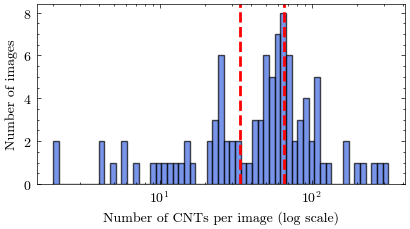

In [5]:
q1 = np.percentile(object_counts, 33)
q2 = np.percentile(object_counts, 66)
plot_cnt_per_image_histogram_log(
    object_counts,
    q1=q1,
    q2=q2,
    save_path=OUTPUTS["density"] / "cnt_count_hist_log.svg"
 )

In [6]:
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
MICRONS_PER_IMAGE = 5

results = {}

for img in images:
    img_id = img["id"]
    anns = [a for a in annotations if a["image_id"] == img_id]

    line_density = compute_line_densities_from_polygons(
        anns,
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        min_object_size=2
    )

    mean_ld = np.mean(line_density)
    mean_ld_per_micron = mean_ld / MICRONS_PER_IMAGE

    results[img["file_name"]] = {
        "line_density": line_density,
        "mean_ld_um": mean_ld_per_micron
    }

mean_densities = np.array([r["mean_ld_um"] for r in results.values()])


Current font sizes:
Font size: 10.0
Axes labelsize: medium
XTick labelsize: medium
YTick labelsize: medium


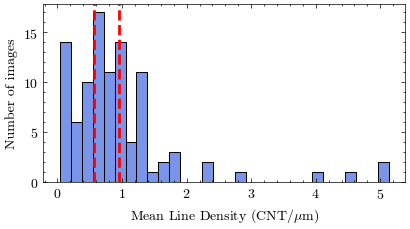

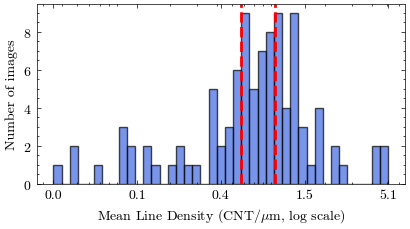

In [7]:
# These red vertical lines are density tertile reference lines for visualization only.
# The actual Low/Mid/High image classes used downstream come from CNT count per image.
plot_line_density_histogram(
    mean_densities,
    save_path=OUTPUTS["density"] / "line_density_hist_linear.svg"
 )

plot_line_density_histogram_log(
    mean_densities,
    save_path=OUTPUTS["density"] / "line_density_hist_log.svg"
 )

,density_display,mean_cnt_count,std_cnt_count,n_images,density_order
0,Low,26.454545,15.686705,11,0
1,Mid,63.500000,7.677529,10,1
2,High,212.111111,73.544960,9,2


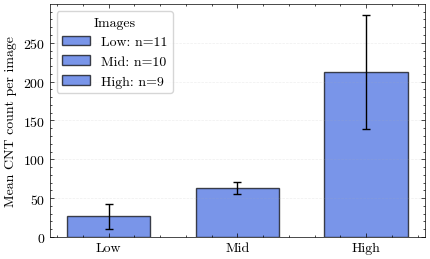

In [8]:
density_csv_path = PROJECT_ROOT / "data" / "annotations_uniques" / "test" / "metadata" / "density_classified_filenames.csv"

density_df = load_density_classification_csv(density_csv_path)

density_summary = summarize_cnt_count_by_density(
    density_df,
    density_col="Density_Tertile",
    count_col="GT Number of Cnts",
)

display(density_summary)

plot_mean_cnt_count_by_density(
    density_summary,
    save_path=OUTPUTS["density"] / "mean_cnt_count_by_density.svg",
    figsize=(4.5, 2.8),
)

Classification source of truth: CNT count tertiles
  Count thresholds: q33=33.670, q66=65.340
  Density tertiles for reference only: q33=0.573187, q66=0.957562


Mean LD tertile class,High,Low,Mid
CNT count class,,,
High,24,2,8
Low,0,26,7
Mid,10,5,18


Agreement with independent density tertiles: 68/100 (68.0%)


,cnt_class,mean_cnt_count,std_cnt_count,n_images,density_display,density_order
0,Low,0.322964,0.245273,33,Low,0
1,Mid,0.838731,0.266270,33,Mid,1
2,High,1.676471,1.242828,34,High,2


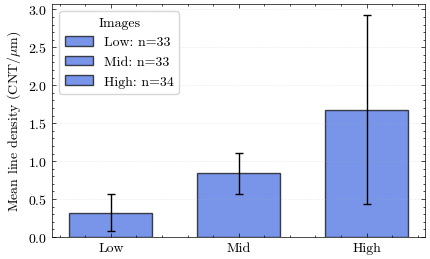

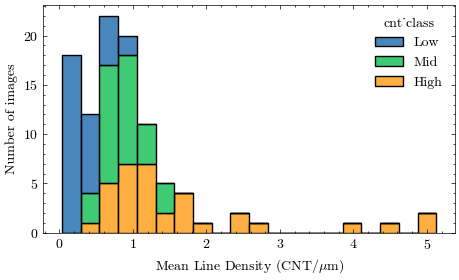

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

count_by_image_id = Counter([ann["image_id"] for ann in annotations])

per_image_rows = []
for img in images:
    img_id = img["id"]
    file_name = img["file_name"]
    cnt_count = int(count_by_image_id.get(img_id, 0))
    mean_ld_um = float(results[file_name]["mean_ld_um"])
    per_image_rows.append(
        {
            "file_name": file_name,
            "gt_cnt_count": cnt_count,
            "mean_ld_um": mean_ld_um,
        }
    )

df_100 = pd.DataFrame(per_image_rows)

cnt_q1 = np.percentile(df_100["gt_cnt_count"], 33)
cnt_q2 = np.percentile(df_100["gt_cnt_count"], 66)
ld_q1 = np.percentile(df_100["mean_ld_um"], 33)
ld_q2 = np.percentile(df_100["mean_ld_um"], 66)

def classify_tertile(value, q1, q2):
    if value <= q1:
        return "Low"
    if value <= q2:
        return "Mid"
    return "High"

df_100["cnt_class"] = df_100["gt_cnt_count"].apply(
    lambda value: classify_tertile(value, cnt_q1, cnt_q2)
 )
df_100["ld_class"] = df_100["mean_ld_um"].apply(
    lambda value: classify_tertile(value, ld_q1, ld_q2)
 )

print("Classification source of truth: CNT count tertiles")
print(f"  Count thresholds: q33={cnt_q1:.3f}, q66={cnt_q2:.3f}")
print(f"  Density tertiles for reference only: q33={ld_q1:.6f}, q66={ld_q2:.6f}")

coherence_table = pd.crosstab(
    df_100["cnt_class"],
    df_100["ld_class"],
    rownames=["CNT count class"],
    colnames=["Mean LD tertile class"],
)
display(coherence_table)

agreement_mask = df_100["cnt_class"] == df_100["ld_class"]
n_match = int(agreement_mask.sum())
n_total = len(df_100)
print(f"Agreement with independent density tertiles: {n_match}/{n_total} ({100 * n_match / n_total:.1f}%)")

density_by_count_class = (
    df_100.groupby("cnt_class", as_index=False)
    .agg(
        mean_cnt_count=("mean_ld_um", "mean"),
        std_cnt_count=("mean_ld_um", "std"),
        n_images=("mean_ld_um", "count"),
    )
 )

density_by_count_class["density_display"] = density_by_count_class["cnt_class"]
density_by_count_class["density_order"] = density_by_count_class["density_display"].map(
    {"Low": 0, "Mid": 1, "High": 2}
 )
density_by_count_class = density_by_count_class.sort_values("density_order").reset_index(drop=True)

display(density_by_count_class)

plot_mean_cnt_count_by_density(
    density_by_count_class,
    save_path=OUTPUTS["density"] / "mean_line_density_by_cnt_class_gt_json_100.svg",
    figsize=(4.5, 2.8),
    ylabel="Mean line density (CNT/$\\mu$m)",
)

plt.figure(figsize=(4.8, 3.0))
sns.histplot(
    data=df_100,
    x="mean_ld_um",
    hue="cnt_class",
    hue_order=["Low", "Mid", "High"],
    bins=20,
    multiple="stack",
    edgecolor="black",
    alpha=0.75,
 )
plt.xlabel("Mean Line Density (CNT/$\\mu$m)")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig(
    OUTPUTS["density"] / "line_density_hist_by_cnt_class_gt_json_100.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0.02,
 )
plt.show()

build count-based classes and independent LD classes

In [10]:
CLASS_ORDER = ["Low", "Mid", "High"]

cnt_q1 = np.percentile(df_100["gt_cnt_count"], 33)
cnt_q2 = np.percentile(df_100["gt_cnt_count"], 66)

ld_q1 = np.percentile(df_100["mean_ld_um"], 33)
ld_q2 = np.percentile(df_100["mean_ld_um"], 66)

def classify_tertile(value, q1, q2):
    if value <= q1:
        return "Low"
    if value <= q2:
        return "Mid"
    return "High"

df_100["cnt_class"] = df_100["gt_cnt_count"].apply(
    lambda x: classify_tertile(x, cnt_q1, cnt_q2)
)

df_100["ld_tertile_class"] = df_100["mean_ld_um"].apply(
    lambda x: classify_tertile(x, ld_q1, ld_q2)
)

print("Source-of-truth classes: GT CNT count tertiles")
print(f"Count thresholds: q33={cnt_q1:.3f}, q66={cnt_q2:.3f}")
print(f"Independent line-density tertiles: q33={ld_q1:.6f}, q66={ld_q2:.6f}")

Source-of-truth classes: GT CNT count tertiles
Count thresholds: q33=33.670, q66=65.340
Independent line-density tertiles: q33=0.573187, q66=0.957562


fit count → line-density mapping

In [11]:
x = df_100["gt_cnt_count"].to_numpy(dtype=float)
y = df_100["mean_ld_um"].to_numpy(dtype=float)

# Linear mapping: mean_line_density = a * count + b
a, b = np.polyfit(x, y, deg=1)

cnt_q1_projected_ld = a * cnt_q1 + b
cnt_q2_projected_ld = a * cnt_q2 + b

pearson_r = np.corrcoef(x, y)[0, 1]
r2 = pearson_r ** 2

print("Linear count → line-density mapping")
print(f"mean_ld_um = {a:.6f} * gt_cnt_count + {b:.6f}")
print(f"Pearson r = {pearson_r:.4f}")
print(f"R² = {r2:.4f}")
print()
print("Projected count thresholds onto line-density axis:")
print(f"Count q33={cnt_q1:.3f} → projected LD={cnt_q1_projected_ld:.6f} CNT/µm")
print(f"Count q66={cnt_q2:.3f} → projected LD={cnt_q2_projected_ld:.6f} CNT/µm")
print()
print("Independent LD tertiles:")
print(f"LD q33={ld_q1:.6f} CNT/µm")
print(f"LD q66={ld_q2:.6f} CNT/µm")

Linear count → line-density mapping
mean_ld_um = 0.014146 * gt_cnt_count + 0.025524
Pearson r = 0.9412
R² = 0.8858

Projected count thresholds onto line-density axis:
Count q33=33.670 → projected LD=0.501820 CNT/µm
Count q66=65.340 → projected LD=0.949823 CNT/µm

Independent LD tertiles:
LD q33=0.573187 CNT/µm
LD q66=0.957562 CNT/µm


classify line density using projected count thresholds

In [12]:
df_100["ld_projected_count_class"] = df_100["mean_ld_um"].apply(
    lambda x: classify_tertile(x, cnt_q1_projected_ld, cnt_q2_projected_ld)
)

conf_independent_ld = pd.crosstab(
    df_100["cnt_class"],
    df_100["ld_tertile_class"],
    rownames=["GT count class"],
    colnames=["Independent LD class"],
).reindex(index=CLASS_ORDER, columns=CLASS_ORDER, fill_value=0)

conf_projected_ld = pd.crosstab(
    df_100["cnt_class"],
    df_100["ld_projected_count_class"],
    rownames=["GT count class"],
    colnames=["Projected-threshold LD class"],
).reindex(index=CLASS_ORDER, columns=CLASS_ORDER, fill_value=0)

display(conf_independent_ld)
display(conf_projected_ld)

agreement_independent = (df_100["cnt_class"] == df_100["ld_tertile_class"]).mean()
agreement_projected = (df_100["cnt_class"] == df_100["ld_projected_count_class"]).mean()

print(f"Agreement using independent LD tertiles: {100 * agreement_independent:.1f}%")
print(f"Agreement using projected count thresholds: {100 * agreement_projected:.1f}%")

Independent LD class,Low,Mid,High
GT count class,,,
Low,26,7,0
Mid,5,18,10
High,2,8,24


Projected-threshold LD class,Low,Mid,High
GT count class,,,
Low,23,10,0
Mid,3,19,11
High,0,10,24


Agreement using independent LD tertiles: 68.0%
Agreement using projected count thresholds: 66.0%


mean line density per actual count class

In [13]:
density_by_count_class = (
    df_100.groupby("cnt_class", as_index=False)
    .agg(
        mean_line_density_um=("mean_ld_um", "mean"),
        std_line_density_um=("mean_ld_um", "std"),
        mean_cnt_count=("gt_cnt_count", "mean"),
        std_cnt_count=("gt_cnt_count", "std"),
        n_images=("mean_ld_um", "count"),
    )
)

density_by_count_class["density_order"] = density_by_count_class["cnt_class"].map(
    {"Low": 0, "Mid": 1, "High": 2}
)

density_by_count_class = (
    density_by_count_class
    .sort_values("density_order")
    .reset_index(drop=True)
)

display(density_by_count_class)

,cnt_class,mean_line_density_um,std_line_density_um,mean_cnt_count,std_cnt_count,n_images,density_order
0,Low,0.322964,0.245273,17.121212,9.453034,33,0
1,Mid,0.838731,0.266270,53.151515,8.754003,33,1
2,High,1.676471,1.242828,124.705882,73.055616,34,2


histogram with both threshold types

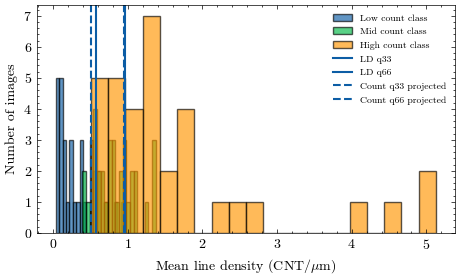

Saved to: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\line_density_hist_with_projected_count_thresholds.svg


In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.8, 3.0))

for cls in CLASS_ORDER:
    values = df_100.loc[df_100["cnt_class"] == cls, "mean_ld_um"]
    ax.hist(
        values,
        bins=20,
        alpha=0.65,
        label=f"{cls} count class",
        edgecolor="black",
        stacked=True,
    )

# Independent line-density tertiles
ax.axvline(ld_q1, linestyle="-", linewidth=1.5, label="LD q33")
ax.axvline(ld_q2, linestyle="-", linewidth=1.5, label="LD q66")

# Count thresholds projected onto LD axis
ax.axvline(cnt_q1_projected_ld, linestyle="--", linewidth=1.5, label="Count q33 projected")
ax.axvline(cnt_q2_projected_ld, linestyle="--", linewidth=1.5, label="Count q66 projected")

ax.set_xlabel("Mean line density (CNT/$\\mu$m)")
ax.set_ylabel("Number of images")
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()

save_path = OUTPUTS["density"] / "line_density_hist_with_projected_count_thresholds.svg"
fig.savefig(save_path, format="svg", bbox_inches="tight", pad_inches=0.02)

plt.show()

print(f"Saved to: {save_path}")

scatter plot showing the mapping

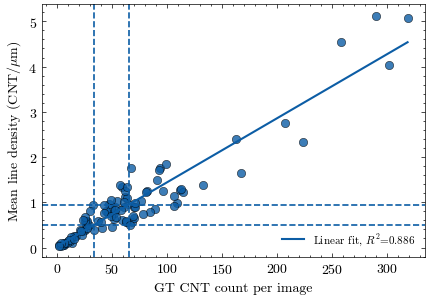

Saved to: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\density\count_vs_line_density_mapping.svg


In [15]:
fig, ax = plt.subplots(figsize=(4.5, 3.2))

ax.scatter(
    df_100["gt_cnt_count"],
    df_100["mean_ld_um"],
    alpha=0.8,
    edgecolor="black",
    linewidth=0.4,
)

x_fit = np.linspace(df_100["gt_cnt_count"].min(), df_100["gt_cnt_count"].max(), 200)
y_fit = a * x_fit + b

ax.plot(x_fit, y_fit, linewidth=1.5, label=f"Linear fit, $R^2$={r2:.3f}")

ax.axvline(cnt_q1, linestyle="--", linewidth=1.2)
ax.axvline(cnt_q2, linestyle="--", linewidth=1.2)
ax.axhline(cnt_q1_projected_ld, linestyle="--", linewidth=1.2)
ax.axhline(cnt_q2_projected_ld, linestyle="--", linewidth=1.2)

ax.set_xlabel("GT CNT count per image")
ax.set_ylabel("Mean line density (CNT/$\\mu$m)")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()

save_path = OUTPUTS["density"] / "count_vs_line_density_mapping.svg"
fig.savefig(save_path, format="svg", bbox_inches="tight", pad_inches=0.02)

plt.show()

print(f"Saved to: {save_path}")

Pearson correlation : 0.9412

Linear      R² = 0.8858
Quadratic   R² = 0.8985
Cubic       R² = 0.9054


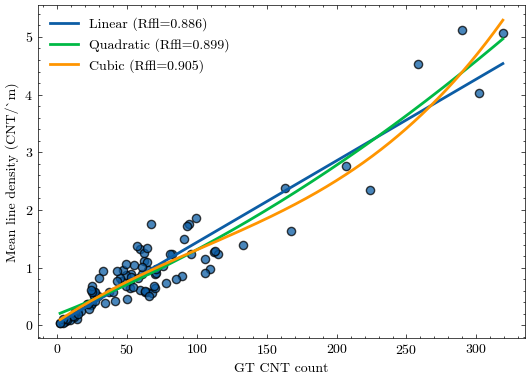

In [16]:
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

x = df_100["gt_cnt_count"].to_numpy(dtype=float)
y = df_100["mean_ld_um"].to_numpy(dtype=float)

models = {}

# -------------------------
# Linear
# -------------------------
coef1 = np.polyfit(x, y, 1)
p1 = np.poly1d(coef1)
y1 = p1(x)

models["Linear"] = {
    "poly": p1,
    "degree": 1,
    "R2": r2_score(y, y1)
}

# -------------------------
# Quadratic
# -------------------------
coef2 = np.polyfit(x, y, 2)
p2 = np.poly1d(coef2)
y2 = p2(x)

models["Quadratic"] = {
    "poly": p2,
    "degree": 2,
    "R2": r2_score(y, y2)
}

# -------------------------
# Cubic
# -------------------------
coef3 = np.polyfit(x, y, 3)
p3 = np.poly1d(coef3)
y3 = p3(x)

models["Cubic"] = {
    "poly": p3,
    "degree": 3,
    "R2": r2_score(y, y3)
}

pearson_r, _ = pearsonr(x, y)

print(f"Pearson correlation : {pearson_r:.4f}")
print()

for name, m in models.items():
    print(f"{name:10s}  R² = {m['R2']:.4f}")

# -------------------------
# Plot
# -------------------------
xx = np.linspace(x.min(), x.max(), 500)

plt.figure(figsize=(5.5,4))

plt.scatter(
    x,
    y,
    s=35,
    alpha=0.75,
    edgecolor="black"
)

for name, m in models.items():
    plt.plot(
        xx,
        m["poly"](xx),
        linewidth=2,
        label=f"{name} (R²={m['R2']:.3f})"
    )

plt.xlabel("GT CNT count")
plt.ylabel("Mean line density (CNT/µm)")
plt.legend()
plt.tight_layout()
plt.show()